In [1]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
import sys
from tqdm import tqdm
sys.path.append("../../Code/Scripts")
from Compressed_Potts import *
from Random_Potts import *
from Frequency_Calculators import *
from Compressed_Potts_sample_generator import *
from scipy.stats import pearsonr
from sklearn.metrics import r2_score


## using MPF Flow (https://arxiv.org/abs/0906.4779) for training lrbm.
## Here we use the MPF flow used in the above paper.


In [2]:
##
Num_site = 6

Num_letter = 4
High_value = 0.5
fraction_high = 0.2


In [3]:
Num_states = Num_letter**Num_site

print("Total Possible States=",Num_states)


if Num_states <100000000:
    States = Construct_States(Num_site, Num_letter)
    States = np.array(States)
    n_s = len(States)
    if Num_states == n_s:
        print("NUmber of States match!")
else:
    print("Should we construct all states?")



Unfurled_States =[]

for elem in States:
    unf_elem = One_hot_encoder(elem, Num_letter)
    Unfurled_States.append(unf_elem)
Unfurled_States = np.array(Unfurled_States)



Total Possible States= 4096
Constructing all states
Number of States from Construction= 4096
NUmber of States match!


In [4]:
Weight_GT, Bias_GT = Potts_Parameter_Creator(Num_site, Num_letter, High_value, fraction_high)

Number of High values= 240


In [5]:
Energy_of_States = Potts_Energy_of_State_Array(Unfurled_States, Weight_GT, Bias_GT)

In [6]:
Temperature = 1
Probability_of_States = Potts_Probability_of_State_Array(Energy_of_States, Temperature)

Text(0.5, 1.0, 'Probability')

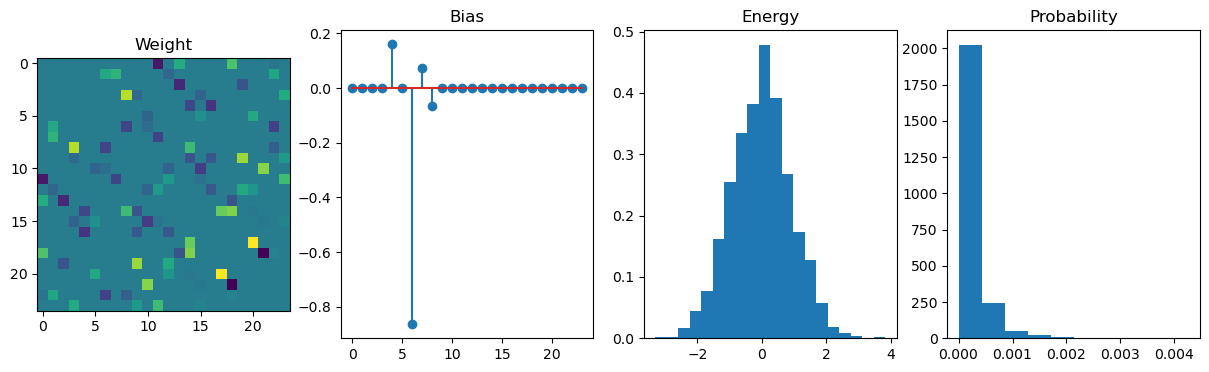

In [7]:
fig, ax = plt.subplots(1,4, figsize=(15,4))
ax[0].imshow(Weight_GT)
ax[1].stem(Bias_GT)
ax[2].hist(Energy_of_States, bins = 20, density = True)
ax[3].hist(Probability_of_States,bins=10, density = True)
ax[0].set_title("Weight")
ax[1].set_title("Bias")
ax[2].set_title("Energy")
ax[3].set_title("Probability")

In [8]:
Sample_Size = [1,2,5,7,10,20,50,70,100,200,300,500,700,900,1000,2000,3000,4000,5000,6000,7000,9000,10000,15000, 20000, 30000]

Sampling_Experiment={}
for elem in Sample_Size:
    Sampling_Experiment[elem] = Sample_From_Distribution(elem, States, Probability_of_States)

In [9]:
### 
Num_unique = []
for elem in Sample_Size:
    Exp_elem = Sampling_Experiment[elem]
    Emp_prob = Exp_elem["Empirical_Probability_for_unique"]

    Num_unique.append(len(Emp_prob))

In [10]:
Emp_Entropy_Array=[]
GT_Entropy_Array= []
for elem in Sample_Size:
    Exp_elem = Sampling_Experiment[elem]
    Emp_prob = Exp_elem["Empirical_Probability_for_unique"]
    GT_prob = Exp_elem["Ground_Truth_Probability_for_unique"]

    GT_prob_norm = np.sum(GT_prob)
    GT_prob/=GT_prob_norm

    Emp_Entropy= -1*np.sum(Emp_prob* np.log(Emp_prob))
    GT_Entropy = -1*np.sum(GT_prob* np.log(GT_prob))

    Emp_Entropy_Array.append(Emp_Entropy)
    GT_Entropy_Array.append(GT_Entropy)



In [11]:
Actual_Entropy_GT = np.sum(-1*Probability_of_States * np.log(Probability_of_States))

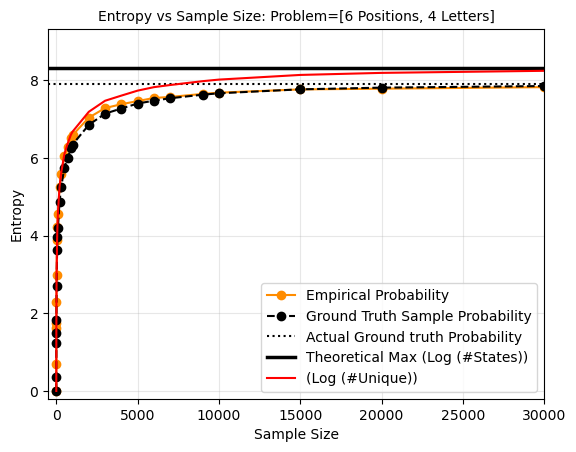

In [ ]:
plt.plot(Sample_Size,Emp_Entropy_Array, "o-", color = "darkorange", label = "Empirical Probability")
plt.plot(Sample_Size,GT_Entropy_Array, "o--", color = "black", label = "Ground Truth Sample Probability")
plt.axhline(Actual_Entropy_GT, color ="black", linestyle = "dotted" ,label = "Actual Ground truth Probability")
plt.xlabel("Sample Size")
plt.ylabel("Entropy")
plt.title(f"Entropy vs Sample Size: Problem=[{Num_site} Positions, {Num_letter} Letters]", fontsize = 10)
plt.axhline(np.log(Num_states), color = "black", linewidth = 2.5, label = "Theoretical Max (Log (#States))")

#plt.plot(Sample_Size, np.log(Sample_Size),label = " Log (# Samples)")
plt.plot(Sample_Size, np.log(Num_unique), color = "red",label ="(Log (#Unique))")
plt.ylim(-0.2,np.log(Num_states)+1)
plt.grid(alpha = 0.3)
plt.xlim(-500,30000)
plt.legend()

save_fig = True
if save_fig:
    plt.savefig("../../Figures/Entropy_Evolution.pdf", dpi = 300)

plt.show()

In [13]:
Correction_MM = (np.array(Num_unique)-1)/(2* np.array(Sample_Size))

S_corr = Emp_Entropy_Array - Correction_MM

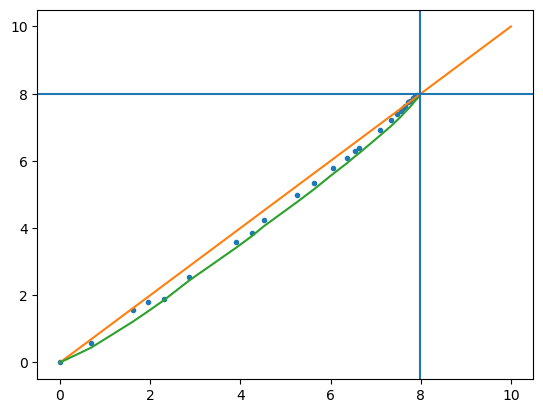

In [14]:
plt.plot(Emp_Entropy_Array,GT_Entropy_Array, ".")
plt.plot(np.arange(0,11,1), np.arange(0,11,1))

plt.plot(Emp_Entropy_Array , S_corr)

plt.axvline(Actual_Entropy_GT)
plt.axhline(Actual_Entropy_GT)

num_unique = 274
300
Sample Size= 300


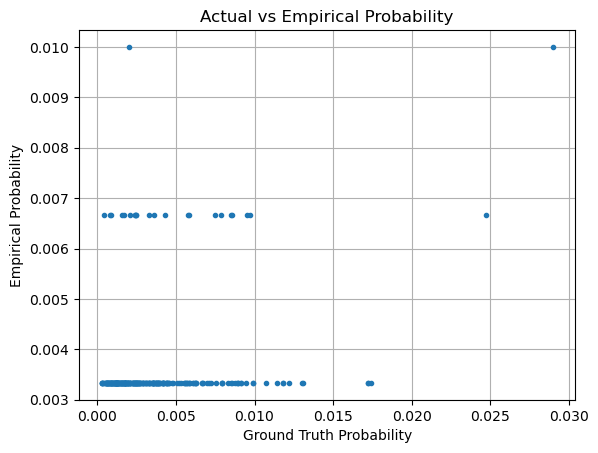

In [22]:
st = 10
k = Sample_Size[st]

Chosen_indices = Sampling_Experiment[k]['Indices_Picked']
Chosen_Data = Sampling_Experiment[k]['Chosen_Compact_States']

Emp_prob_k = Sampling_Experiment[k]['Empirical_Probability_for_unique']
GT_prob_k = Sampling_Experiment[k]['Ground_Truth_Probability_for_unique']
Unique_index = Sampling_Experiment[k]['Unique_indices']
print("num_unique =", len(Unique_index))

print(len(Chosen_Data))

print("Sample Size=", k)
plt.plot(Sampling_Experiment[k]["Ground_Truth_Probability_for_unique"], Sampling_Experiment[k]["Empirical_Probability_for_unique"], ".")
plt.xlabel("Ground Truth Probability")
plt.ylabel("Empirical Probability")
plt.title("Actual vs Empirical Probability")
plt.grid()
plt.show()

In [23]:
def estimate_GT_sample_entropy(multiplicities, N):
    M    = len(multiplicities)
    p    = multiplicities / N
    H_emp = -np.sum(p * np.log(p + 1e-300))
    n1   = np.sum(multiplicities == 1)
    f1   = (n1-1) / (N)
    
    # missing mass correction (dominant)
    missing_correction  = f1 * H_emp
    # variance correction (Miller-Madow)
    variance_correction = (M -1) / (2 * N)
    
    H_target = H_emp - missing_correction - variance_correction
    
    return H_target, H_emp, f1 , variance_correction



U, C = np.unique(Chosen_Data, axis = 0, return_counts= True)

A = estimate_GT_sample_entropy(C, np.sum(C))
print(A)

(np.float64(0.4936252692081214), np.float64(5.580148642400713), np.float64(0.83), np.float64(0.455))


In [24]:
P = []
Q = []
R = []
Sugg = []
f_val = []
MM_corr_val = []
for m in range(0, len(Sample_Size)):
    n = Sample_Size[m]
    Chosen_indices_m= Sampling_Experiment[n]['Indices_Picked']
    Chosen_Data_m = Sampling_Experiment[n]['Chosen_Compact_States']
    U, C = np.unique(Chosen_Data_m, axis = 0, return_counts= True)
    A_m = estimate_GT_sample_entropy(C, np.sum(C))

    Sing_corr = A_m[1] - (A_m[2])
    MM_corr = A_m[1] - A_m[3]
    MM_corr_act = Sing_corr + A_m[3]

    P.append(Sing_corr)
    Q.append(MM_corr)
    R.append(MM_corr_act)
    Sugg.append(A_m[0])
    f_val.append(A_m[2])
    MM_corr_val.append(A_m[3])


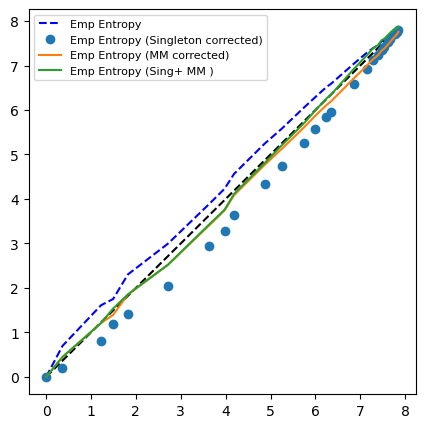

In [25]:
#C = np.array(Emp_Entropy_Array) - 0.5* (((Num_letter** Num_site - np.array(Num_unique))/(Num_letter** Num_site) ) * (f_val) + np.array(MM_corr_val))

plt.figure(figsize=(5,5))
plt.plot(GT_Entropy_Array, Emp_Entropy_Array, "b--", label = "Emp Entropy")
plt.plot(GT_Entropy_Array, GT_Entropy_Array, "k--")
plt.plot(GT_Entropy_Array, P, "o",  label = "Emp Entropy (Singleton corrected)")
plt.plot(GT_Entropy_Array, Q, label = "Emp Entropy (MM corrected)")
plt.plot(GT_Entropy_Array, R, label = "Emp Entropy (Sing+ MM )")

#plt.plot(GT_Entropy_Array, C , label = "Exp")
plt.legend(fontsize = 8)


No Correction= 0.24401028285996465
Sing. Correction= 0.37639019967021503
MM . Correction= 0.1361463755253798
MM+ Sing Corr= 0.08884554485606794


Text(0.5, 1.0, 'Entropy Correction: Problem=[6 Positions, 4 Letters]')

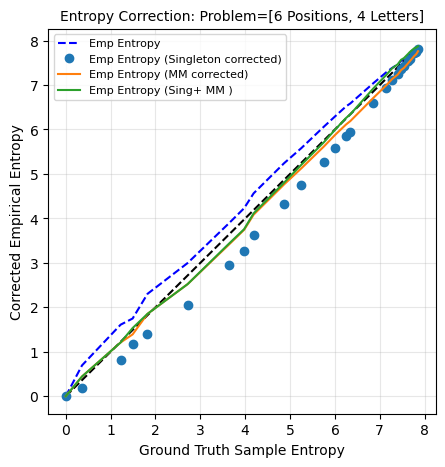

In [29]:
plt.figure(figsize=(5,5))
plt.plot(GT_Entropy_Array, Emp_Entropy_Array, "b--", label = "Emp Entropy")
plt.plot(GT_Entropy_Array, GT_Entropy_Array, "k--")
plt.plot(GT_Entropy_Array, P, "o",  label = "Emp Entropy (Singleton corrected)")
plt.plot(GT_Entropy_Array, Q, label = "Emp Entropy (MM corrected)")
plt.plot(GT_Entropy_Array, R, label = "Emp Entropy (Sing+ MM )")

plt.xlabel("Ground Truth Sample Entropy")
plt.ylabel("Corrected Empirical Entropy")
plt.grid(alpha = 0.3)
plt.legend(fontsize = 8)


print("No Correction=",np.sqrt(np.mean((np.array(GT_Entropy_Array) - np.array(Emp_Entropy_Array))**2)))
print("Sing. Correction=",np.sqrt(np.mean((np.array(GT_Entropy_Array) - np.array(P))**2)))
print("MM . Correction=",np.sqrt(np.mean((np.array(GT_Entropy_Array) - np.array(Q))**2)))
print("MM+ Sing Corr=",np.sqrt(np.mean((np.array(GT_Entropy_Array) - np.array(R))**2)))
plt.title(f"Entropy Correction: Problem=[{Num_site} Positions, {Num_letter} Letters]", fontsize = 10)



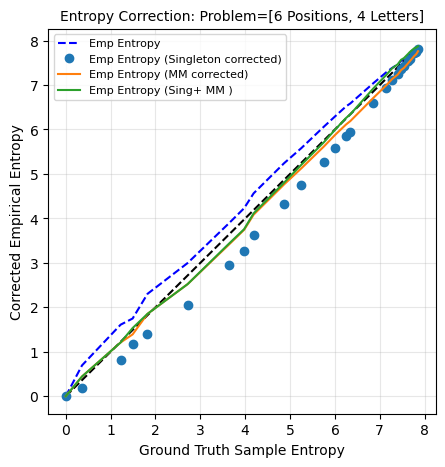

In [30]:
plt.figure(figsize=(5,5))
plt.plot(GT_Entropy_Array, Emp_Entropy_Array, "b--", label = "Emp Entropy")
plt.plot(GT_Entropy_Array, GT_Entropy_Array, "k--")
plt.plot(GT_Entropy_Array, P, "o",  label = "Emp Entropy (Singleton corrected)")
plt.plot(GT_Entropy_Array, Q, label = "Emp Entropy (MM corrected)")
plt.plot(GT_Entropy_Array, R, label = "Emp Entropy (Sing+ MM )")
plt.title(f"Entropy Correction: Problem=[{Num_site} Positions, {Num_letter} Letters]", fontsize = 10)

plt.xlabel("Ground Truth Sample Entropy")
plt.ylabel("Corrected Empirical Entropy")
plt.grid(alpha = 0.3)
plt.legend(fontsize = 8)
save_fig = True
if save_fig:
    plt.savefig("../../Figures/Entropy_correction.pdf", dpi = 300)

plt.show()


In [31]:
Potts_out = Compressed_Potts(Chosen_Data, compressed=False)
Outflow_out=[]
Probability_Array_Evolution_0 = []
Sample_Prob_Evolution_0 = []
Property = Potts_out.Fast_Single_Mutants_Sorter_Partition_for_Training_Data_OPTIMIZED(0)

Number of Partitions Set= 1
..Setting Partition Map..
Number of partitions = 1
Initializing with score matching ...
Initializing with score matching ...


In [32]:
Unique_compact_data = np.unique(Chosen_Data, axis = 0)
Unique_unfurled_data = []
for u in Unique_compact_data:
    u_unf = Potts_out.One_hot_encoder(u)
    Unique_unfurled_data.append(u_unf)
Unique_unfurled_data = np.array(Unique_unfurled_data)

In [33]:
lr =0.01
n_epochs = 500

In [34]:
Train = True
if Train:
    for i in tqdm(range(0, n_epochs)):
        out = Potts_out.Exact_Min_Outflow_Single_Iteration_Parameter_Update(Property, lr, method = 1)
        Outflow_out.append(out)

        Energy_of_States_out_exp_i = Potts_Energy_of_State_Array(Unfurled_States, Potts_out.Weights[0], Potts_out.Bias[0])
        Prob_i = Potts_Probability_of_State_Array(Energy_of_States_out_exp_i, 1)
        Probability_Array_Evolution_0.append(Prob_i)


        Sample_States_energy_i = Potts_Energy_of_State_Array(Unique_unfurled_data, Potts_out.Weights[0], Potts_out.Bias[0])
        Prob_samp_i = Potts_Probability_of_State_Array(Sample_States_energy_i, 1)
        Sample_Prob_Evolution_0.append(Prob_samp_i)
        
    print("Training_Method =", Potts_out.method)

else:
    print("Training is Off!")

  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:03<00:00, 165.33it/s]

Training_Method = MPF


In [35]:
Actual_Entropy = np.sum(-1 * Probability_of_States * np.log(Probability_of_States))
Probability_Array_Evolution_van = np.array(Probability_Array_Evolution_0)
Entropy_evol_van = np.sum(-1 * Probability_Array_Evolution_van * np.log(Probability_Array_Evolution_van), axis = 1)

Sample_Prob_Evolution_van = np.array(Sample_Prob_Evolution_0)
Sample_Entropy_evol_van = np.sum(-1 * Sample_Prob_Evolution_van * np.log(Sample_Prob_Evolution_van), axis = 1)


Pearson_prob = []
RMSE_prob = []

for p in Probability_Array_Evolution_van:
    p_corr = pearsonr(p, Probability_of_States)[0]
    rmse_corr = np.sqrt(np.mean((p - Probability_of_States)**2))
    Pearson_prob.append(p_corr)
    RMSE_prob.append(rmse_corr)

    
Pearson_arg = np.argmax(Pearson_prob)
RMSE_arg = np.argmin(RMSE_prob)
Entropy_arg = np.argmin(np.abs(Entropy_evol_van- Actual_Entropy_GT))
                        
Arg_list = [Pearson_arg, RMSE_arg, Entropy_arg, -1]

A_stop = []

for i in range(5,20):
    Cross_Ent = np.sum(-1* Sample_Prob_Evolution_van * np.log(Sample_Prob_Evolution_van[i]), axis = 1)

    Arg_stop = np.argmin(Cross_Ent)
    A_stop.append(Arg_stop)
    
print(Arg_stop)

248


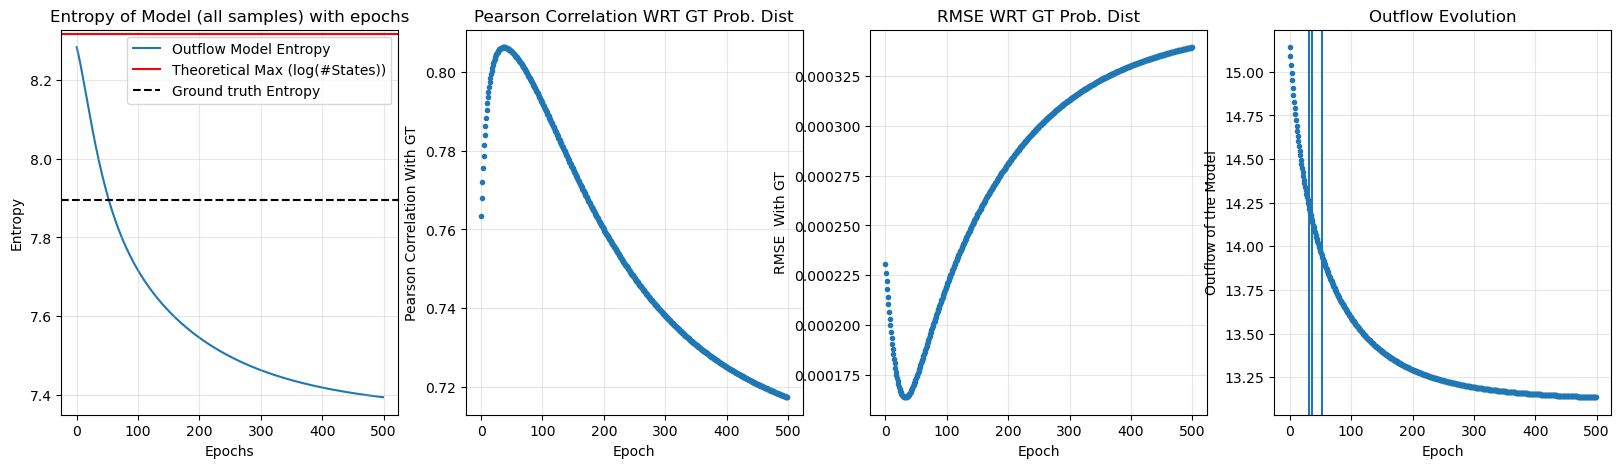

In [36]:
fig, ax = plt.subplots(1,4, figsize=(20,5))

ax[0].plot(Entropy_evol_van, label = "Outflow Model Entropy", zorder = 0)
ax[0].grid(alpha = 0.3)
ax[0].axhline(np.log(Num_states), color = "red", label = "Theoretical Max (log(#States))")
ax[0].axhline(Actual_Entropy_GT, color = "black", linestyle = "dashed",label = "Ground truth Entropy")
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Entropy")
ax[0].set_title("Entropy of Model (all samples) with epochs")
ax[0].legend()
#plt.xlim(0,100)

ax[1].plot(Pearson_prob, ".")
ax[1].grid(alpha = 0.3)
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Pearson Correlation With GT")
ax[1].set_title("Pearson Correlation WRT GT Prob. Dist")


ax[2].plot(RMSE_prob, ".")
ax[2].grid(alpha = 0.3)
ax[2].set_xlabel("Epoch")
ax[2].set_ylabel("RMSE  With GT")
ax[2].set_title("RMSE WRT GT Prob. Dist")


ax[3].plot(Outflow_out, ".")
ax[3].grid(alpha = 0.3)
ax[3].set_xlabel("Epoch")
ax[3].set_ylabel("Outflow of the Model")
ax[3].set_title("Outflow Evolution")

for i in range(0,3):
    ax[3].axvline(Arg_list[i])


plt.show()

In [37]:
len(Sample_Prob_Evolution_van[0])
len(Emp_prob_k)

274

32


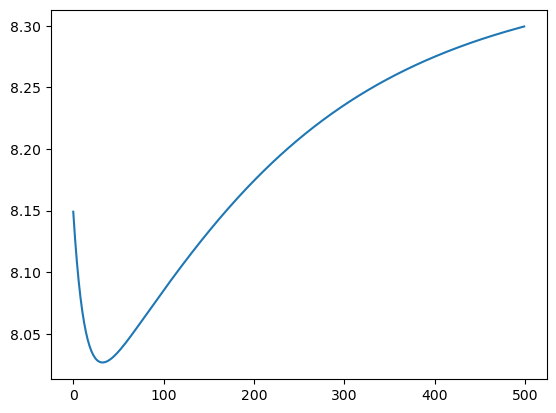

In [38]:
def Cross_Ent(P, Q):
    kld = np.sum(-1 * P * np.log(Q))
    return kld

### What about GT and Probability_Array Cross Entropy?
C_ent_GT=[]
for p in Probability_Array_Evolution_van:

    C_p = Cross_Ent(Probability_of_States, p)

    C_ent_GT.append(C_p)


plt.plot(C_ent_GT)
print(np.argmin(C_ent_GT))

np.int64(291)

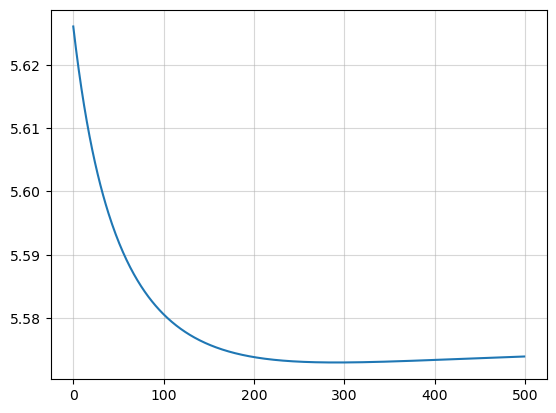

In [39]:
C_ent = []
for p in Sample_Prob_Evolution_van:
    k = Cross_Ent(p,Emp_prob_k)
    plt.grid(alpha = 0.5)
    C_ent.append(k)

plt.plot(C_ent)
np.argmin(C_ent)

Text(0.5, 1.0, 'MPF Fit')

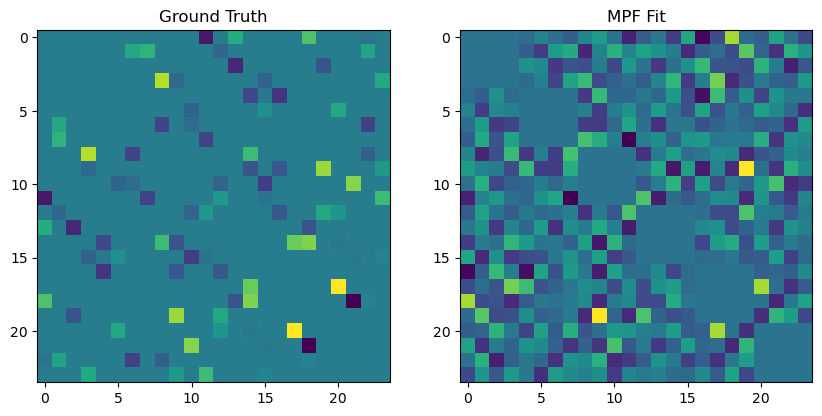

In [40]:
### Lets test this model:

fig, ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(Weight_GT)
ax[0].set_title("Ground Truth")
ax[1].imshow(Potts_out.Weights[0])
ax[1].set_title("MPF Fit")

## Lets draw from learned model:


In [41]:
Energy_of_States_learned = Potts_Energy_of_State_Array(Unfurled_States, Potts_out.Weights[0], Potts_out.Bias[0])
Probability_of_States_learned =  Potts_Probability_of_State_Array(Energy_of_States_learned, Temperature)

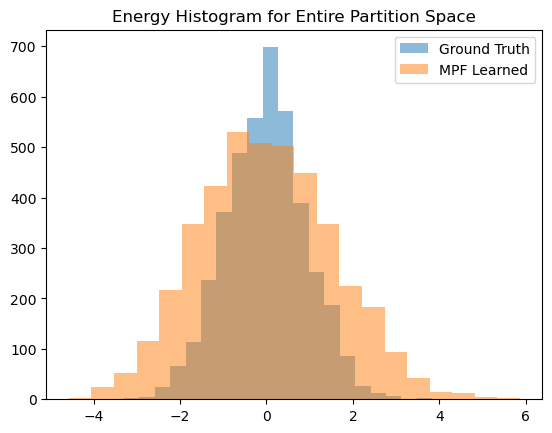

In [47]:
plt.hist(Energy_of_States, 20, alpha = 0.5, label = "Ground Truth")
plt.hist(Energy_of_States_learned, 20, alpha = 0.5, label = "MPF Learned")
plt.legend()
plt.title("Energy Histogram for Entire Partition Space")
save_fig = True
if save_fig:
    plt.savefig("../../Figures/Energy_Histogram.pdf", dpi = 300)

plt.show()


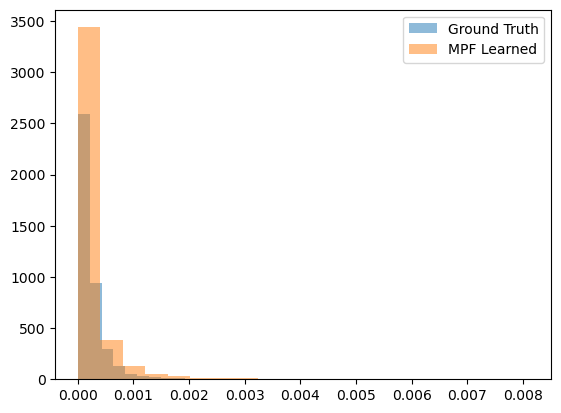

In [48]:
plt.hist(Probability_of_States, 20, alpha = 0.5, label = "Ground Truth")
plt.hist(Probability_of_States_learned, 20, alpha = 0.5, label = "MPF Learned")
plt.legend()
plt.show()


In [49]:
## Lets now draw from the model and GT:

Sample_Size = [1,2,5,7,10,20,50,70,100,200,300,500,700,900,1000,2000,3000,4000,5000,6000,7000,9000,10000,15000, 20000, 30000]

Sampling_Experiment_learned={}
for elem in Sample_Size:
    Sampling_Experiment_learned[elem] = Sample_From_Distribution(elem, States, Probability_of_States_learned)

In [50]:
Chosen_size = Sample_Size[15]

Data_GT = Sampling_Experiment[Chosen_size]['Chosen_Compact_States']
Data_learned = Sampling_Experiment_learned[Chosen_size]['Chosen_Compact_States']

Data_GT_ohe = []
Data_learned_ohe = []

for d in Data_GT:
    d_ohe = Potts_out.One_hot_encoder(d)
    Data_GT_ohe.append(d_ohe)

for d in Data_learned:
    d_ohe = Potts_out.One_hot_encoder(d)
    Data_learned_ohe.append(d_ohe)


Ohe_dataset_1 = np.array(Data_GT_ohe)

Ohe_dataset_2 = np.array(Data_learned_ohe)

In [51]:
### ------ For natural or Ground Truth (GT) Data ------

## since triplet calculations are slow, I set it to false here
## set it to true if you want to do them

### ----------------------------------------------------

Sing_Freq_GT= Singlet_Frequency(Ohe_dataset_1, Num_letter)
PW_Freq_GT,_ = Pairwise_Frequency(Ohe_dataset_1, Num_letter)
PW_Corr_GT,_ = Pairwise_Correlation(Ohe_dataset_1, Num_letter)

### ------ For LRBM Data ------
Sing_Freq_LRBM= Singlet_Frequency(Ohe_dataset_2, Num_letter)
PW_Freq_LRBM,_ = Pairwise_Frequency(Ohe_dataset_2, Num_letter)
PW_Corr_LRBM,_ = Pairwise_Correlation(Ohe_dataset_2, Num_letter)


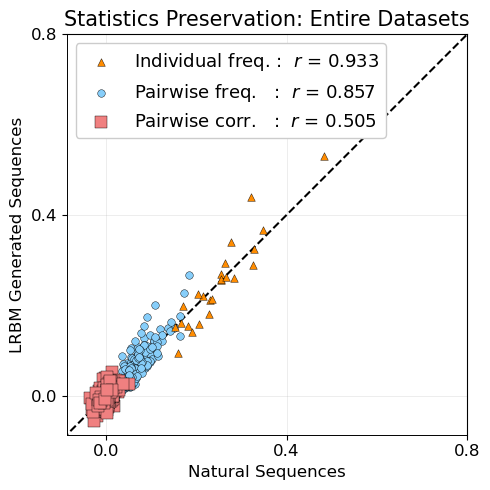

In [55]:

# ----Your data  (it could be by partition or whole)-------------
# Replace each with your actual 1D arrays (one value per position/pair/triplet - not the matrix)

individual_nat  = np.array(Sing_Freq_GT)
individual_syn  = np.array(Sing_Freq_LRBM)

pairwise_freq_nat  = np.array(PW_Freq_GT)
pairwise_freq_syn  = np.array(PW_Freq_LRBM)

pairwise_corr_nat  = np.array(PW_Corr_GT)
pairwise_corr_syn  = np.array(PW_Corr_LRBM)



datasets = [
    dict(nat=individual_nat,   syn=individual_syn,
        label='Individual freq. ',  color='darkorange', marker='^', size=30, edgecolor = "black", zorder = 3),
    dict(nat=pairwise_freq_nat, syn=pairwise_freq_syn,
        label='Pairwise freq.   ',    color='lightskyblue', marker='o', size=30, edgecolor = "black", zorder = 2),
    dict(nat=pairwise_corr_nat, syn=pairwise_corr_syn,
        label='Pairwise corr.   ',    color='lightcoral', marker='s', size=65, edgecolor = "black", zorder = 3)
]


for d in datasets:
    r2   = r2_score(d['nat'], d['syn'])
    rmse = np.sqrt(np.mean((d['nat'] - d['syn']) ** 2))
    pson_r= pearsonr(d['nat'], d['syn'])[0]
    d['r2']= r2
    d['rmse']= rmse
    d['pearson_r'] = pson_r

# ── Figure ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))

# Determine global axis limits across all datasets
all_nat = np.concatenate([d['nat'] for d in datasets])
all_syn = np.concatenate([d['syn'] for d in datasets])
lo = min(all_nat.min(), all_syn.min())
hi = max(all_nat.max(), all_syn.max())
pad = (hi - lo) * 0.05
lo, hi = lo - pad, hi + pad



# Scatter each statistic + annotation
annotation_y = 0.97  # tracks vertical position of text annotations
for d in datasets:
    
    pson = d['pearson_r']
    label_o = f"{d['label']}:  $r$ = {pson :.3f}"
    ax.scatter(d['nat'], d['syn'],
               color=d['color'], marker=d['marker'],
               s=d['size'], alpha=1, linewidths=0.3,
               edgecolors=d['edgecolor'], zorder=d['zorder'], label=label_o)

    annotation_y -= 0.07

# ── Axes formatting ───────────────────────────────────────────────────
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect('equal')
ax.set_xlabel('Natural Sequences', fontsize=12)
ax.set_ylabel('LRBM Generated Sequences', fontsize=12)
ax.set_title('Statistics Preservation: Entire Datasets', fontsize=15)


ax.tick_params(labelsize=10)
ax.grid(linewidth=0.4, alpha=0.4, zorder=0)

ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(True)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(0.7)

# Legend (shapes/colors only, no duplicating the text annotations)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, fontsize=13, frameon=True,
          framealpha=1, edgecolor='#cccccc',
          loc='upper left')
#plt.xlim(-0.2,1)
#plt.ylim(-0.2,1)
# 1:1 diagonal
ax.plot([-0.2, 1], [-0.2, 1], color='black', linewidth=1.5,
        linestyle='--', zorder=1)


ax.set_xticks([0,0.4,0.8])
ax.set_yticks([0,0.4,0.8])
ax.tick_params(labelsize = 12)

plt.tight_layout()


save = True
Fig_path = "../../Figures/"
if save == True:

    plt.savefig(Fig_path+'statistics_preservation.pdf', transparent= True, dpi=300, bbox_inches='tight')

plt.show()